<a href="https://colab.research.google.com/github/karl262/ECBD-HipolitoSerranoCarlos/blob/main/Notebook/Lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset
dfDirty = pd.read_csv("ventas-por-factura.csv")

In [3]:
dfDirty.shape

(25953, 6)

In [4]:
dfDirty.head(10)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"
5,576630,11/16/2021 8:38:00,13816.0,Germany,91,"199,98"
6,538125,12/9/2020 15:46:00,18225.0,United Kingdom,16,"30,00"
7,544354,2/18/2021 10:42:00,13489.0,United Kingdom,64,"77,28"
8,546369,3/11/2021 11:41:00,15513.0,United Kingdom,10,"67,50"
9,570651,10/11/2021 13:34:00,14911.0,EIRE,86,"321,35"


In [5]:
dfDirty.tail(10)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25945,579252,11/28/2021 16:47:00,17450.0,United Kingdom,432,"1034,40"
25946,574908,11/7/2021 15:37:00,16009.0,United Kingdom,28,"82,76"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [6]:
dfDirty.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [7]:
dfDirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [8]:
# Verificamos los valores nulos
dfDirty.isnull().sum()

,0
N° de factura,0
Fecha de factura,0
ID Cliente,3724
País,0
Cantidad,0
Monto,0


In [9]:
dfDirty.dtypes

,0
N° de factura,object
Fecha de factura,object
ID Cliente,float64
País,object
Cantidad,int64
Monto,object


# Análisis de la información obtenida y proceso a seguir.

# Análisis
Modificación de tipos en columnas:
- Fecha de factura
- Monto
- Datos nulos en ID Cliente
- Valores menores a cero

# Proceso a seguir

*   Normalización de datos
*   Modificación de datos en columnas
*   Obtención de medias y gráficas
*   Conclusiones y justificación de las decisiones





In [10]:
# Realizar una copia de los datos
dfDirty = dfDirty.copy()

In [11]:
# Como primer paso tenemos que pasar el tipo de monto a float en lugar de string para evitar problemas en cálculos
dfDirty[ "Monto" ] = dfDirty[ "Monto" ].astype(str).str.replace(',', '.').astype(float)

In [12]:
# Como segundo paso tenemos que convertir el tipo de la fecha a datetime
dfDirty[ "Fecha de factura" ] = pd.to_datetime(dfDirty[ "Fecha de factura"])

In [13]:
# Validamos los cambios aplicados
dfDirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     25953 non-null  object        
 1   Fecha de factura  25953 non-null  datetime64[ns]
 2   ID Cliente        22229 non-null  float64       
 3   País              25953 non-null  object        
 4   Cantidad          25953 non-null  int64         
 5   Monto             25953 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [14]:
# Comenzamos la limpieza de los datos quitando las facturas que inicien con C o c
# dfDirty = dfDirty[ ~dfDirty[ "N° de factura"].astype(str).str.startswith(("C", "c"))]
# 1. Crear un 'flag' (columna nueva) para identificar facturas canceladas sin borrarlas
dfDirty['Cancelada'] = dfDirty['N° de factura'].astype(str).str.startswith(('C', 'c')).astype(int)

In [15]:
# Como la cantidad de Clients ID nulos es demasiado alta y tenemos información ligada a esos datos, optaremos por asignarles un ID genérico
dfDirty[ "ID Cliente" ] = dfDirty[ "ID Cliente" ].fillna("Cliente_generico")

In [16]:
# Para los datos negativos optaremos por convertirlos a NaN
dfDirty.loc[ dfDirty[ "Cantidad" ] <= 0, "Cantidad" ] = np.nan
dfDirty.loc[ dfDirty[ "Monto" ] <= 0, "Monto" ] = np.nan

In [17]:
dfDirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     25953 non-null  object        
 1   Fecha de factura  25953 non-null  datetime64[ns]
 2   ID Cliente        25953 non-null  object        
 3   País              25953 non-null  object        
 4   Cantidad          20774 non-null  float64       
 5   Monto             20005 non-null  float64       
 6   Cancelada         25953 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 1.4+ MB


In [18]:
dfDirty.duplicated().sum()

np.int64(10)

In [19]:
# Eliminamos valores duplicados
dfDirty = dfDirty.drop_duplicates()

In [20]:
# Normalizamos los paises que no tengan valor a Desconocido
dfDirty['País'] = dfDirty['País'].replace('Unspecified', 'Desconocido')

In [21]:
# Validamos el proceso que hemos realizado
dfDirty.shape

(25943, 7)

In [22]:
dfDirty.head(15)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Cancelada
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123.0,229.33,0
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163.0,209.73,0
2,C570727,2021-10-12 11:32:00,12471.0,Germany,NaN,NaN,1
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1.0,39.95,0
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357.0,344.83,0
5,576630,2021-11-16 08:38:00,13816.0,Germany,91.0,199.98,0
6,538125,2020-12-09 15:46:00,18225.0,United Kingdom,16.0,30.00,0
7,544354,2021-02-18 10:42:00,13489.0,United Kingdom,64.0,77.28,0
8,546369,2021-03-11 11:41:00,15513.0,United Kingdom,10.0,67.50,0
9,570651,2021-10-11 13:34:00,14911.0,EIRE,86.0,321.35,0


In [23]:
dfDirty.tail(15)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Cancelada
25938,553883,2021-05-19 15:31:00,16672.0,United Kingdom,48.0,100.80,0
25939,C572450,2021-10-24 12:35:00,Cliente_generico,United Kingdom,NaN,NaN,1
25940,542527,2021-01-28 12:48:00,17188.0,United Kingdom,266.0,522.08,0
25941,542731,2021-01-31 15:27:00,13600.0,United Kingdom,324.0,219.52,0
25942,541247,2021-01-16 12:44:00,12989.0,United Kingdom,648.0,810.00,0
25943,C557061,2021-06-16 14:55:00,14895.0,United Kingdom,NaN,NaN,1
25944,C562147,2021-08-03 10:47:00,16180.0,United Kingdom,NaN,NaN,1
25945,579252,2021-11-28 16:47:00,17450.0,United Kingdom,432.0,1034.40,0
25946,574908,2021-11-07 15:37:00,16009.0,United Kingdom,28.0,82.76,0
25947,C553519,2021-05-17 14:16:00,18218.0,United Kingdom,NaN,NaN,1


In [24]:
dfDirty[["Cantidad", "Monto"]].isnull().sum()

,0
Cantidad,5173
Monto,5941


Text(0.5, 1.0, 'Identificación de Anomalías: Mapa de calor de Valores Default (Cantidades y Montos Inválidos)')

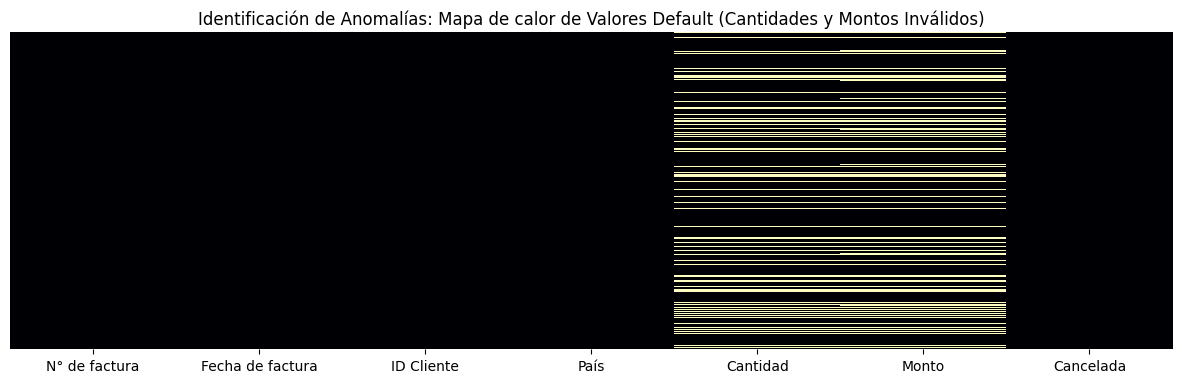

In [25]:
plt.figure(figsize=(15, 14))
# 1. Heatmap de valores nulos (Dataset Crudo vs Procesado visualmente)
plt.subplot(3, 1, 1)
# Mostramos los nulos del dataset limpio para evidenciar dónde están ahora los NaN que creamos a propósito
sns.heatmap(dfDirty.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title('Identificación de Anomalías: Mapa de calor de Valores Default (Cantidades y Montos Inválidos)')


Text(0, 0.5, 'País')

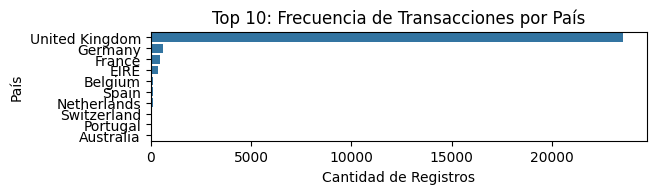

In [26]:
# 2. Ventas por país (Top 10)
plt.subplot(3, 1, 2)
top_paises = dfDirty['País'].value_counts().head(10)
sns.barplot(x=top_paises.values, y=top_paises.index)
plt.title('Top 10: Frecuencia de Transacciones por País')
plt.xlabel('Cantidad de Registros')
plt.ylabel('País')

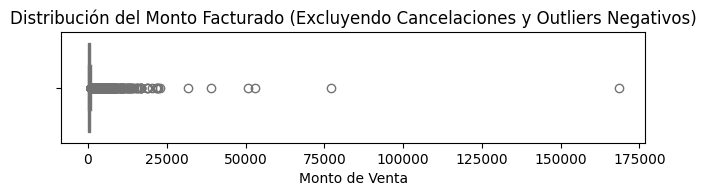

In [28]:
# 3. Distribución del monto con filtración de facturas válidas
plt.subplot(3, 1, 3)
facturas_validas = dfDirty[dfDirty['Cancelada'] == 0]
sns.boxplot(x=facturas_validas['Monto'], color='lightgreen')
plt.title('Distribución del Monto Facturado (Excluyendo Cancelaciones y Outliers Negativos)')
plt.xlabel('Monto de Venta')

plt.tight_layout()
plt.show()

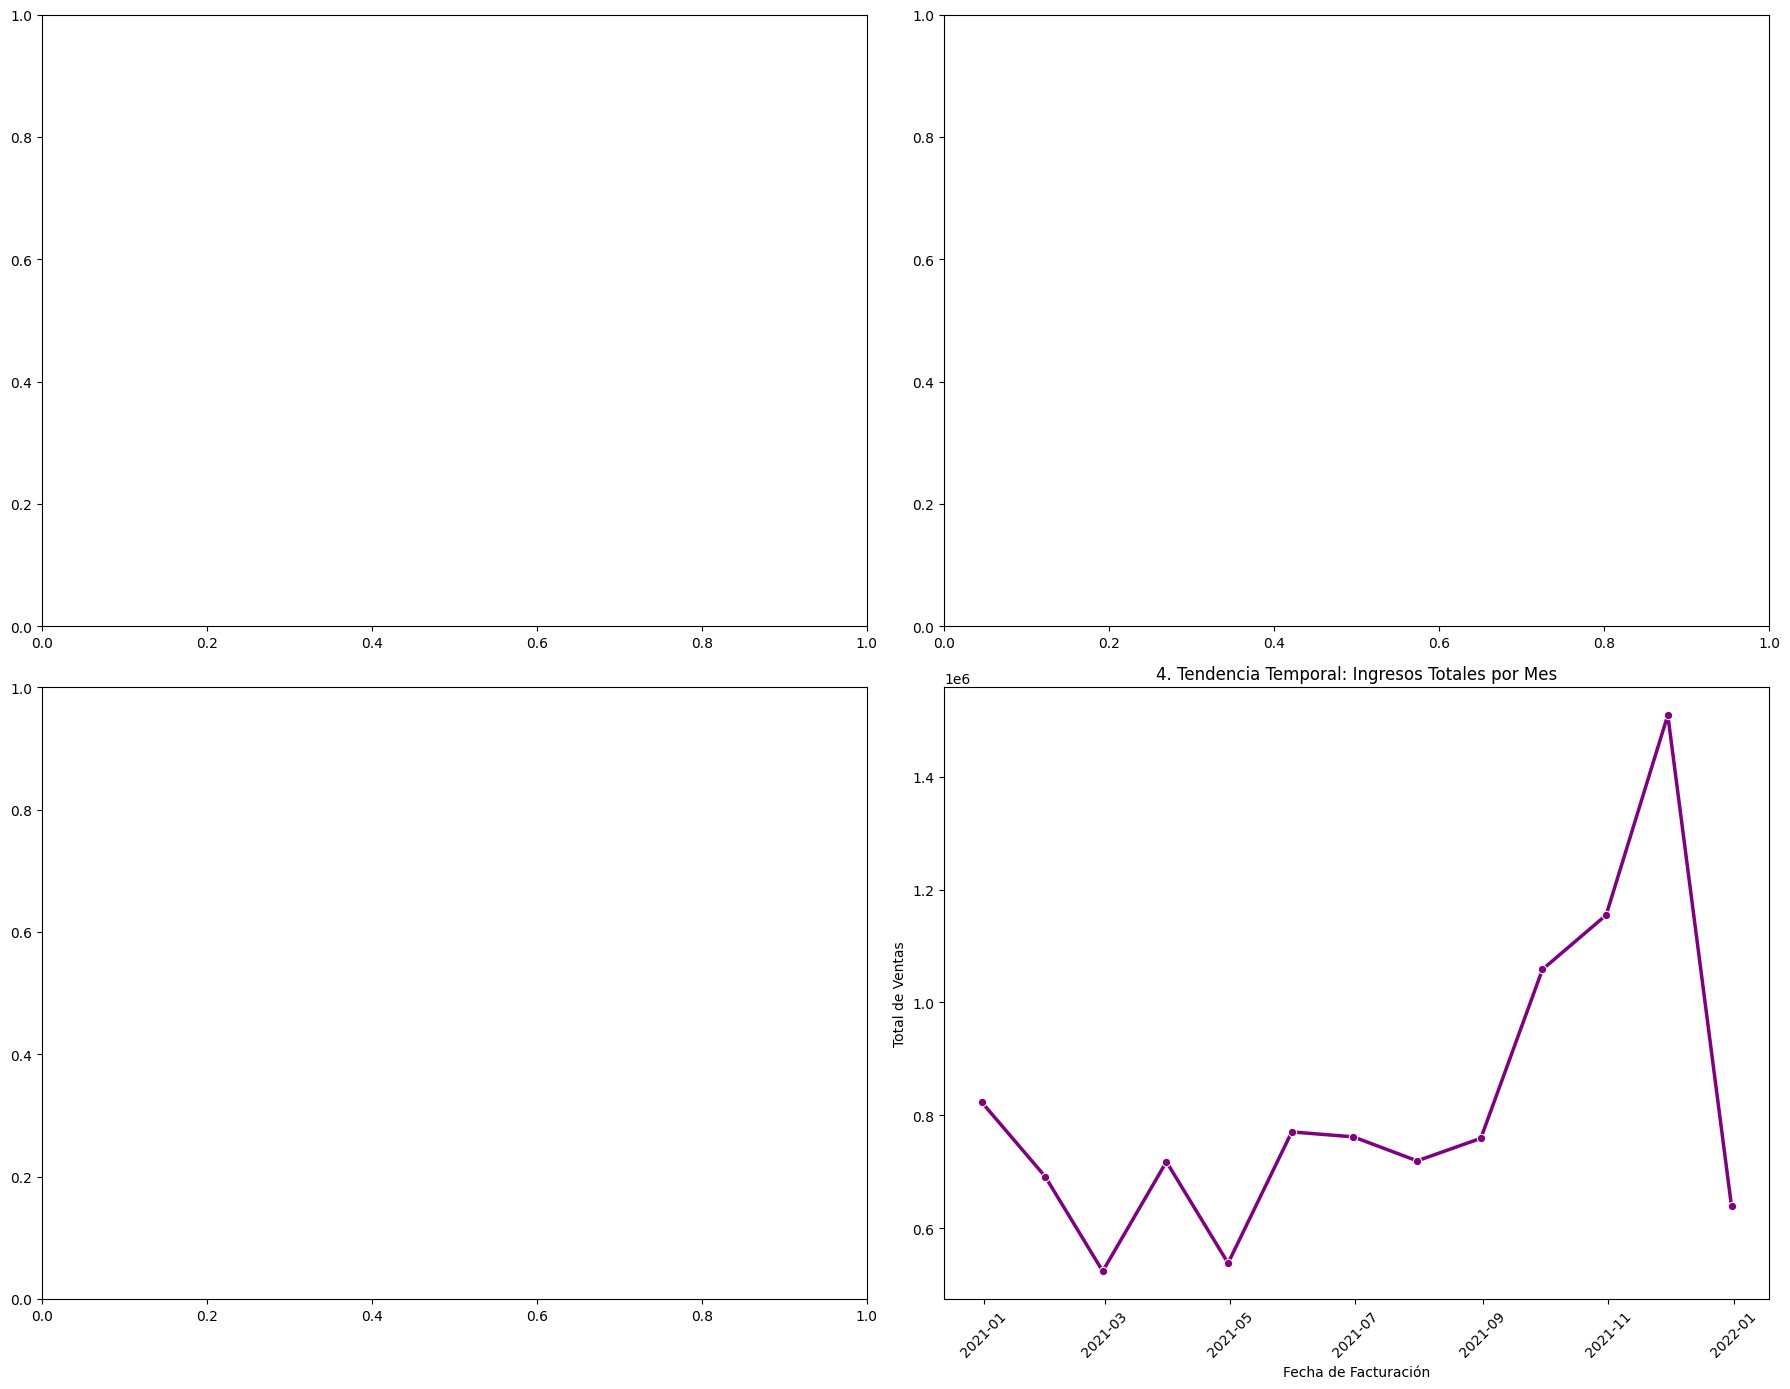

In [33]:
# 4. Agrupamos por mes utilizando la fecha transformada y sumamos los montos
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ventas_mensuales = dfDirty[dfDirty['Cancelada'] == 0].set_index('Fecha de factura').resample('ME')['Monto'].sum()

sns.lineplot(x=ventas_mensuales.index, y=ventas_mensuales.values, marker='o', color='purple', linewidth=2.5, ax=axes[1, 1])
axes[1, 1].set_title('4. Tendencia Temporal: Ingresos Totales por Mes')
axes[1, 1].set_xlabel('Fecha de Facturación')
axes[1, 1].set_ylabel('Total de Ventas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
# Exportamos el DataFrame procesado a un archivo CSV (sin guardar el índice numérico)
dfDirty.to_csv("DataSet_Limpio_Ventas_Factura.csv", index=False)
print("El proceso ha finalizado. Archivo 'Data_Limpio_Factura.csv' exportado exitosamente.")

El proceso ha finalizado. Archivo 'Data_Limpio_Factura.csv' exportado exitosamente.


## 4. Conclusiones y Procedimiento

### Justificación de las decisiones tomadas:
Durante esta práctica se priorizó la preservación de la información sobre la eliminación de registros problemáticos:
1. **Valores Nulos en ID Cliente:** En lugar de eliminar el ~23% del dataset (6,044 filas), se imputó el valor `'Cliente_Generico'`. Esto permite retener datos financieros y de inventario valiosos sin inventar perfiles falsos (random) que arruinarían el análisis de clientes reales.
2. **Facturas Canceladas y Valores Negativos:** No se eliminaron. Las facturas canceladas se etiquetaron en una nueva columna de nombre (`Cancelada`) para permitir futuros análisis de devoluciones. Los valores negativos y ceros en `Cantidad` y `Monto` se transformaron en `NaN`. Esta técnica evita perder la fila completa (manteniendo la trazabilidad del evento) pero impide que los valores ilógicos sesguen los cálculos estadísticos.
3. **Formatos de datos:** Se convirtió el `Monto` reemplazando comas por puntos para que Python lo reconociera como valor numérico continuo, habilitando así el análisis cuantitativo.
4. **Justificación de la Gráfica Temporal:** La incorporación de la gráfica de línea de tiempo permitió consolidar el esfuerzo de transformación de la columna `Fecha de factura`. Sin la conversión estricta a formato `datetime` y el remuestreo (`resample`), habría sido imposible estructurar cronológicamente las tendencias de ingresos del negocio, lo que añade una dimensión de análisis de negocio (**"Business Intelligence"**) que el dataset crudo bloqueaba por completo debido a sus problemas de formato (GIGO).

### **¿Cómo afecta el principio GIGO (Garbage In, Garbage Out) al análisis de datos y Machine Learning?**
El principio GIGO establece que un modelo solo será tan bueno como los datos que lo alimentan.
* **En el Análisis de Datos:** Si no hubiéramos transformado los valores de `Monto` (de texto a número), no podríamos calcular el total de ingresos. Si hubiéramos mantenido las cantidades negativas o duplicados sin tratamiento, los reportes mostrarían ventas infladas, llevando a malas decisiones directivas.
* **En Machine Learning:** Los algoritmos son sensibles al ruido. Si rellenáramos los `ID Cliente` nulos con datos aleatorios, un modelo de clusterización (como K-Means) crearía perfiles de consumo falsos. Al crear la columna `Cancelada` y usar `NaN` para los valores negativos, le estamos indicando explícitamente al algoritmo dónde hay datos de reversión y dónde falta información confiable, permitiendo que el modelo generalice correctamente patrones de venta reales.